# ExperimentExpt 8: Clustering of Countries with World Bank API
## Name: Sufiyan Mehsanewala
## Class: SE AIML 
## Roll no: 44

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
def fetch_indicator(code, year = '2022'):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name = code)

In [5]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [6]:
df = pd.concat([gdp, pop, life, lit], axis = 1)

df.columns = ["GDP", "Population", "LifeExpectancy", "Literacy"]

df.dropna(inplace=True)

df.head()


,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [7]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

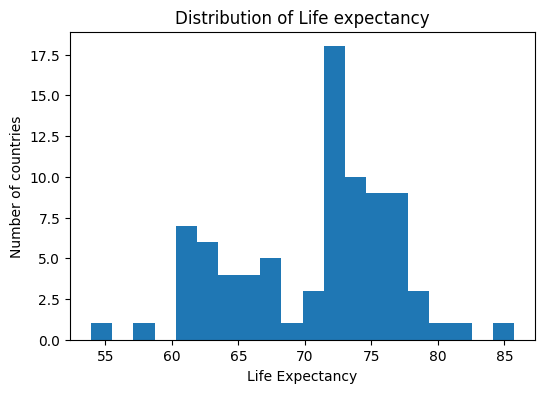

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(df["LifeExpectancy"], bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of Life expectancy")
plt.show()

# Elbow Method

k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


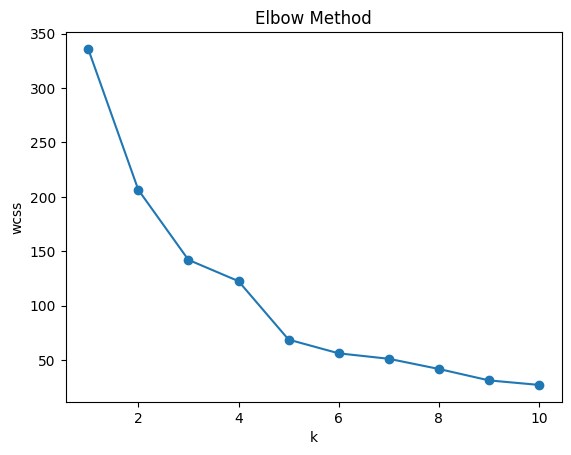

In [11]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i + 1, "\t", wcss[i])

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

# Clustering Algorithms

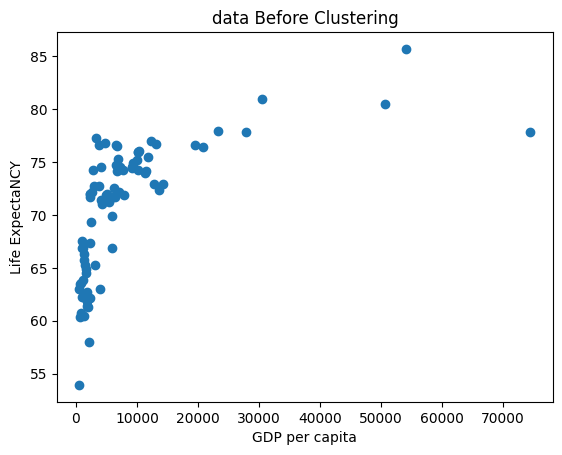

In [15]:
plt.scatter(df["GDP"], df["LifeExpectancy"])

plt.xlabel("GDP per capita")
plt.ylabel("Life ExpectaNCY")
plt.title("data Before Clustering")
plt.show()

In [16]:
kmeans = KMeans(n_clusters = 3, random_state=0)

labels_km = kmeans.fit_predict(X_scaled)

df["KMeansCluster"] = labels_km

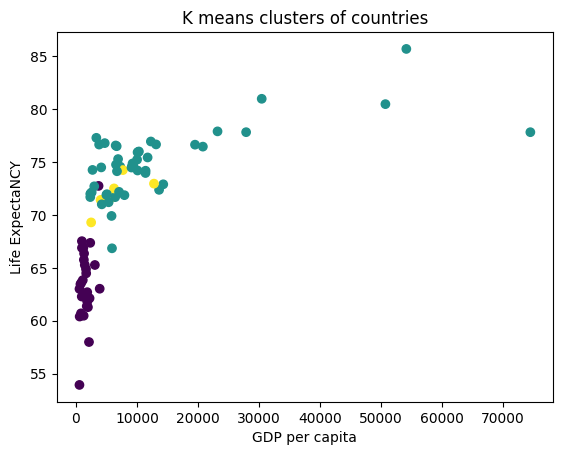

In [18]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_km)

plt.xlabel("GDP per capita")
plt.ylabel("Life ExpectaNCY")
plt.title("K means clusters of countries")
plt.show()

In [19]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

df["HierarchicalCluster"] = labels_hc

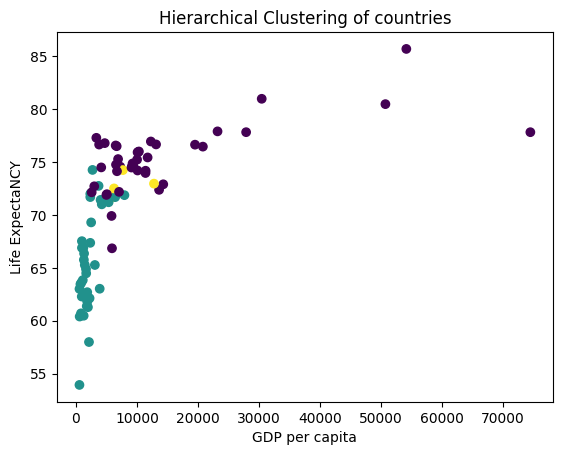

In [21]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_hc)

plt.xlabel("GDP per capita")
plt.ylabel("Life ExpectaNCY")
plt.title("Hierarchical Clustering of countries")
plt.show()

In [25]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687


In [28]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country: India
GDP per capita: 1425423212.0
Life Expectancy: 71.698
Literacy Rate:  76.3199996948242
KMeans Cluster:  1.0
Hierarchical Cluster:  1.0


In [30]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country: North America
GDP per capita: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate:  98.7891464233398
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [31]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country: Brazil
GDP per capita: 210306415.0
Life Expectancy: 74.872
Literacy Rate:  94.3853874531348
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [34]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country: Viet Nam
GDP per capita: 99680655.0
Life Expectancy: 74.502
Literacy Rate:  96.129997253418
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [35]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country: Bahrain
GDP per capita: 1524693.0
Life Expectancy: 80.992
Literacy Rate:  97.870002746582
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0
